In [1]:
from google.colab import files
dataf = files.upload()

Saving electricity_production_data.csv to electricity_production_data.csv


In [2]:
import pandas as pd
data = pd.read_csv("/content/electricity_production_data.csv")
data.shape

(3638, 11)

In [3]:
data.head()

,Unnamed: 0,COUNTRY,CODE_TIME,TIME,YEAR,MONTH,MONTH_NAME,PRODUCT,VALUE,DISPLAY_ORDER,yearToDate
0,13,Australia,JAN2010,January 2010,2010,1,January,Final consumption,19317.931,20,220091.029
1,18,Australia,JAN2010,January 2010,2010,1,January,Low carbon,1665.783,26,24610.860
2,21,Austria,JAN2010,January 2010,2010,1,January,Wind,200.966,2,1961.814
3,81,Canada,JAN2010,January 2010,2010,1,January,Not specified,248.000,13,2976.000
4,91,Canada,JAN2010,January 2010,2010,1,January,Non-renewables,20850.285,23,218831.866


In [4]:
data = data.drop(columns=['Unnamed: 0','CODE_TIME','TIME','MONTH_NAME','DISPLAY_ORDER','yearToDate'], axis=1)

In [5]:
print(data['YEAR'].min())
print(data['YEAR'].max())
print(data['YEAR'].value_counts().sort_index())

2010
2022
YEAR
2010    224
2011    236
2012    245
2013    229
2014    267
2015    291
2016    290
2017    259
2018    333
2019    324
2020    316
2021    334
2022    290
Name: count, dtype: int64


In [6]:
data.shape

(3638, 5)

In [7]:
print(data.info())
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3638 entries, 0 to 3637
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   COUNTRY  3638 non-null   object 
 1   YEAR     3638 non-null   int64  
 2   MONTH    3638 non-null   int64  
 3   PRODUCT  3638 non-null   object 
 4   VALUE    3638 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 142.2+ KB
None


,YEAR,MONTH,VALUE
count,3638.000000,3638.000000,3638.000000
mean,2016.427433,6.513469,18852.283377
std,3.670223,3.430477,77042.459443
min,2010.000000,1.000000,-4446.411000
25%,2013.000000,4.000000,63.964528
50%,2017.000000,7.000000,812.975408
75%,2020.000000,9.000000,4903.570928
max,2022.000000,12.000000,975961.029000


In [8]:
data.isnull().sum()
data.duplicated().sum()

np.int64(0)

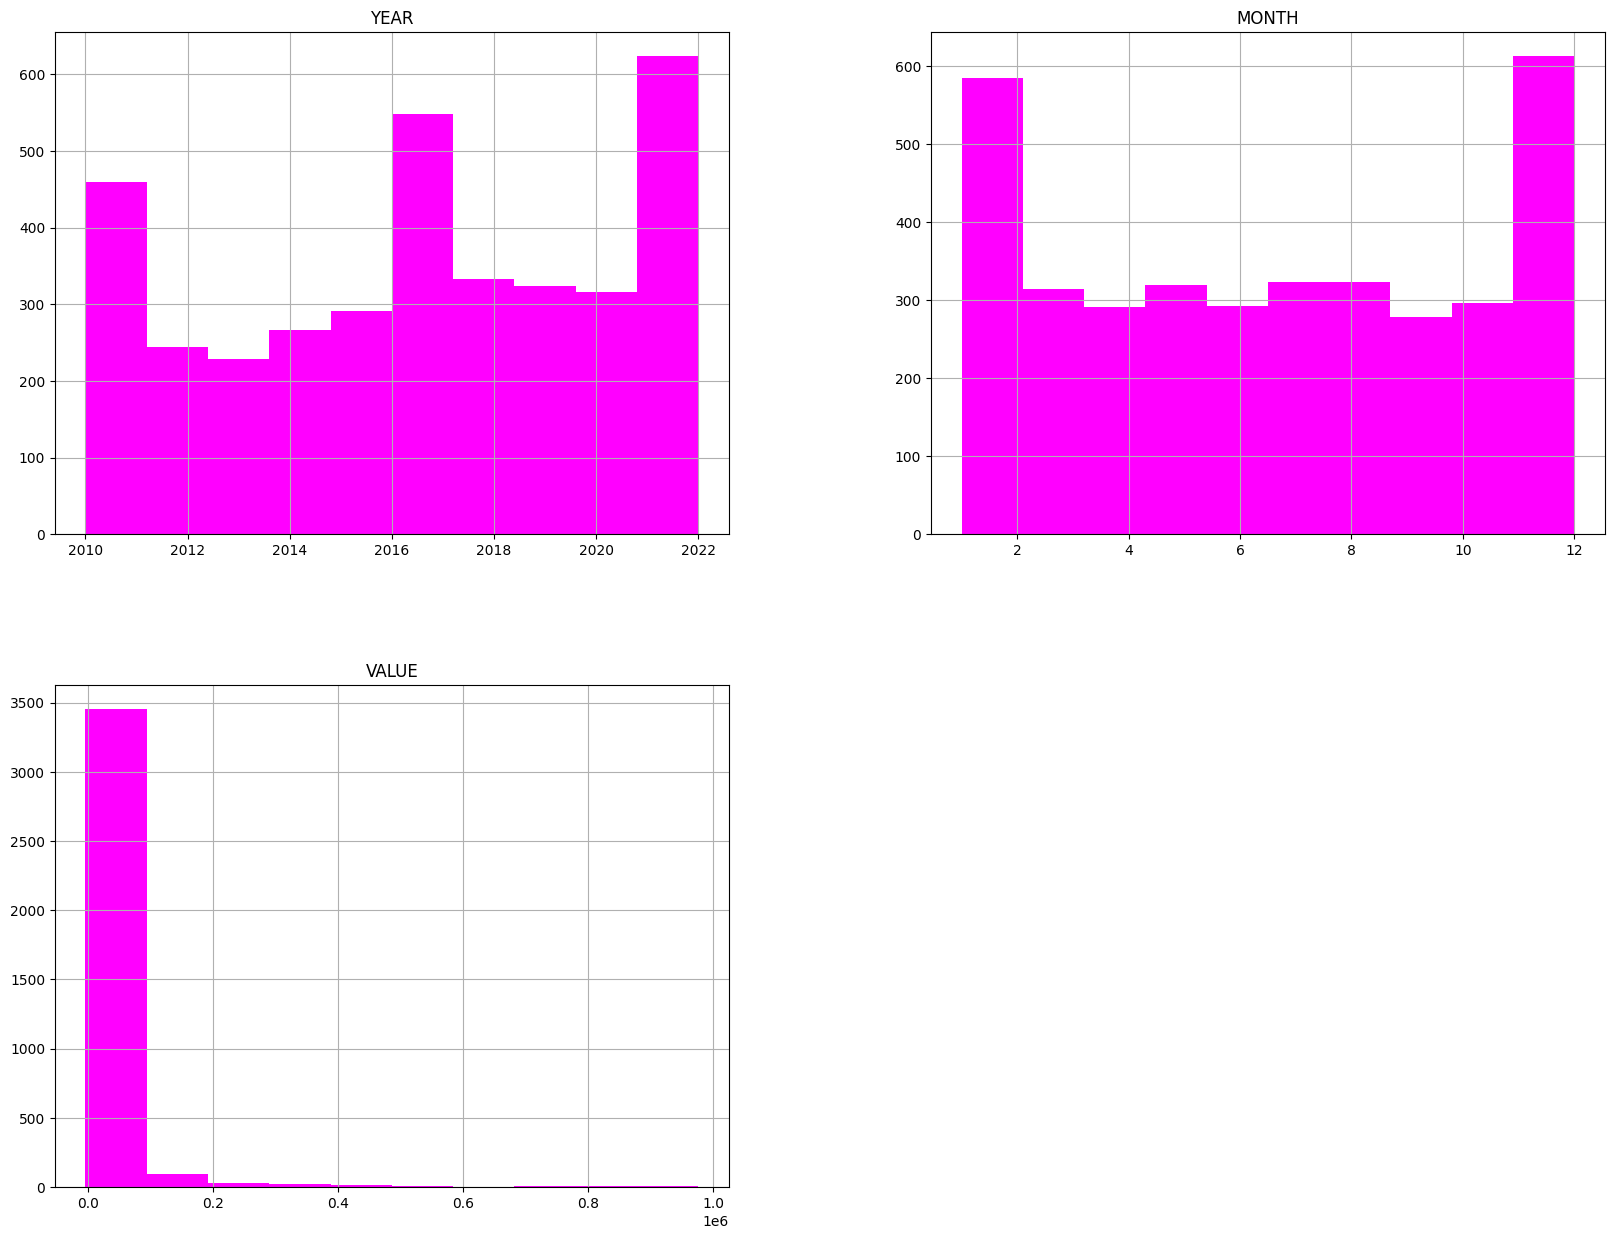

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
data.hist(bins=10, figsize=(20,15),color='magenta')
plt.show()

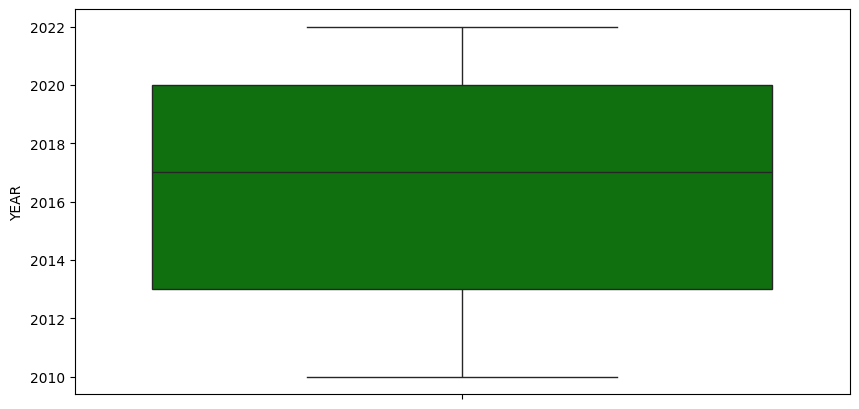

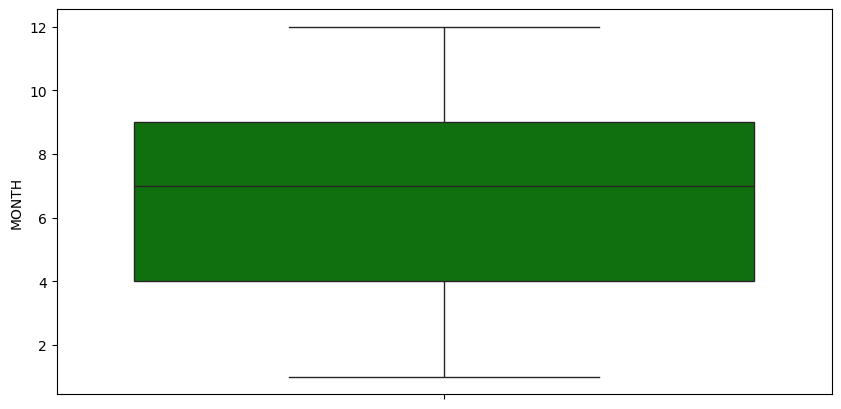

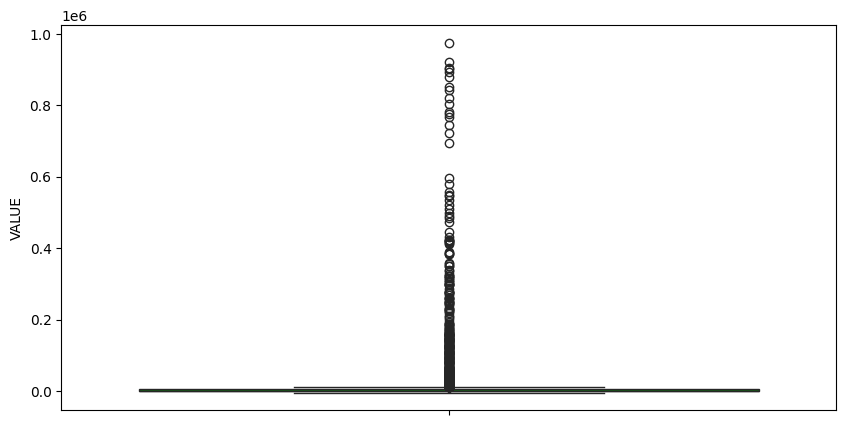

In [10]:
columns = ['YEAR','MONTH','VALUE']
for col in columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(data[col],color='green')

  plt.show()

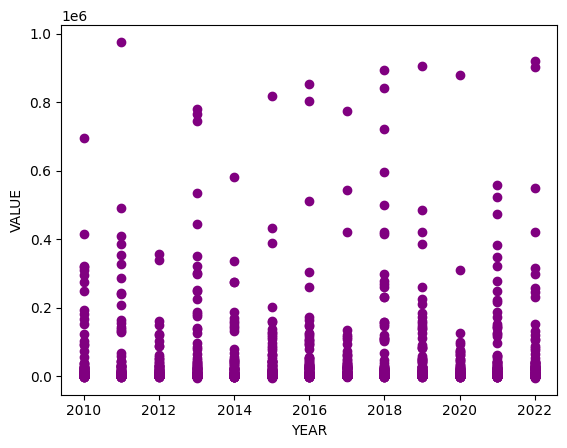

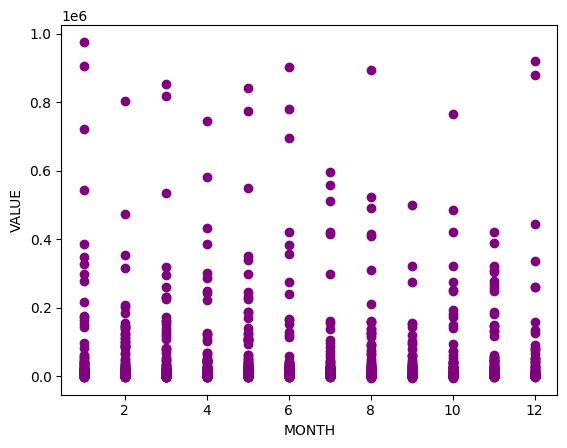

In [11]:
column =['YEAR','MONTH']
for col in column:
  plt.scatter(data[col],data['VALUE'], color='purple')
  plt.xlabel(col)
  plt.ylabel('VALUE')
  plt.show()

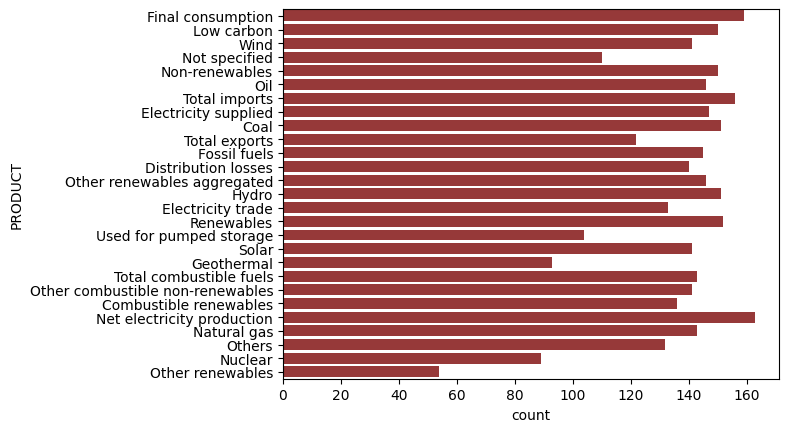

In [12]:
  sns.countplot(data['PRODUCT'], color='brown')
  plt.show()



<Axes: >

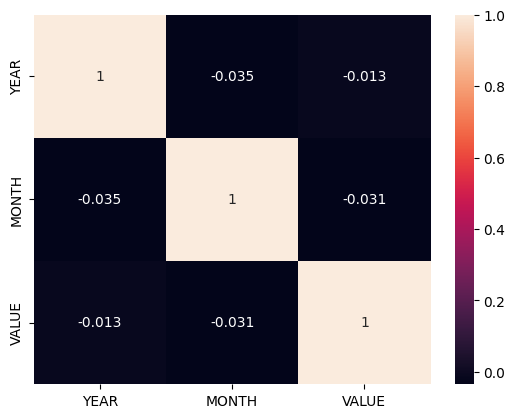

In [13]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)

In [14]:
X = data.drop(columns=['VALUE'])
y = data['VALUE']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

trf1 = ColumnTransformer([
    ('onehot',
     OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'),
     ['COUNTRY', 'PRODUCT'])
], remainder='passthrough')

In [17]:
# X_train_transformed = trf1.fit_transform(X_train)
# X_test_transformed = trf1.transform(X_test)

In [18]:
# X_train_transformed.shape, X_test_transformed.shape

In [19]:
from xgboost import XGBRegressor

trf2= XGBRegressor()


In [20]:
pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2)
])

In [21]:
pipe.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['COUNTRY', 'PRODUCT'])])),
                ('trf2',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rou...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [22]:
pipe.score(X_test,y_test), pipe.score(X_train,y_train)

(0.9297308324114414, 0.9902636920348562)

In [23]:
prediction = pipe.predict(X_test)
prediction

array([-1.11608557e+03, -9.46868835e+02,  4.18377734e+03,  2.97363375e+05,
       -5.34344971e+02, -2.61779614e+03,  1.06423555e+05,  5.48393250e+02,
       -2.00726978e+03, -3.73915863e+02,  2.29740503e+03, -2.89694312e+03,
        4.94702979e+03,  1.85358184e+04, -1.22382666e+03,  6.54434521e+03,
        8.20623828e+03, -1.81440039e+03,  3.00395844e+05, -1.92017371e+03,
       -1.79586511e+03, -1.53394592e+03,  2.42099609e+04,  1.40147734e+04,
       -3.17587012e+03,  1.72303848e+04,  1.49503887e+04,  3.60372461e+04,
       -2.20456812e+03,  5.20246533e+03,  5.05639746e+03,  9.99479395e+03,
       -2.18739502e+03,  5.24173188e+05,  1.77147754e+04,  1.87892188e+03,
        3.63122583e+03, -1.25856763e+03,  1.28984016e+05,  4.38368848e+03,
        3.56863359e+04,  1.49265125e+03,  2.77294883e+04, -4.20921112e+02,
        4.18934082e+03, -1.63832471e+03, -2.32141553e+03, -1.71080884e+03,
        4.12168213e+03, -7.18309448e+02,  6.29695361e+03, -2.08859595e+03,
        6.32658350e+03,  

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, prediction)
mse = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, prediction)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 7625.59616491404
MSE: 322603685.307782
RMSE: 17961.171601757553
R²: 0.9297308324114414


In [25]:
from sklearn import set_config
set_config(display='diagram')


In [26]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2').mean()

np.float64(0.7687956640165842)

In [27]:
import pickle as pkl
pkl.dump(pipe, open('pipe.pkl', 'wb'))

In [28]:
Pipe = pkl.load(open('pipe.pkl', 'rb'))